# Mushroom Edibility — Exploratory Data Analysis

We explore the **UCI Agaricus-Lepiota** dataset: which categorical attributes of a mushroom (cap shape/color, odor, gills, stalk, habitat...) help us classify it as **edible** or **poisonous**.

**Dataset**: 8,124 mushrooms, 22 categorical attributes, target = `class` (e=edible, p=poisonous).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/mushrooms.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8124, 23)


,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap_shape                 8124 non-null   object
 2   cap_surface               8124 non-null   object
 3   cap_color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill_attachment           8124 non-null   object
 7   gill_spacing              8124 non-null   object
 8   gill_size                 8124 non-null   object
 9   gill_color                8124 non-null   object
 10  stalk_shape               8124 non-null   object
 11  stalk_root                8124 non-null   object
 12  stalk_surface_above_ring  8124 non-null   object
 13  stalk_surface_below_ring  8124 non-null   object
 14  stalk_color_above_ring  

In [4]:
print("Unique values per feature:")
for c in df.columns:
    print(f"  {c:30s}: {df[c].nunique():2d}  -> {sorted(df[c].unique().tolist())}")

Unique values per feature:
  class                         :  2  -> ['e', 'p']
  cap_shape                     :  6  -> ['b', 'c', 'f', 'k', 's', 'x']
  cap_surface                   :  4  -> ['f', 'g', 's', 'y']
  cap_color                     : 10  -> ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
  bruises                       :  2  -> ['f', 't']
  odor                          :  9  -> ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
  gill_attachment               :  2  -> ['a', 'f']
  gill_spacing                  :  2  -> ['c', 'w']
  gill_size                     :  2  -> ['b', 'n']
  gill_color                    : 12  -> ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']
  stalk_shape                   :  2  -> ['e', 't']
  stalk_root                    :  5  -> ['?', 'b', 'c', 'e', 'r']
  stalk_surface_above_ring      :  4  -> ['f', 'k', 's', 'y']
  stalk_surface_below_ring      :  4  -> ['f', 'k', 's', 'y']
  stalk_color_above_ring        :  9  -> ['b', 'c', 'e'

In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing markers ('?') per column:")
for c in df.columns:
    n = (df[c] == "?").sum()
    if n: print(f"  {c}: {n}")

Duplicate rows: 0
Missing markers ('?') per column:
  stalk_root: 2480


## 4. Target Variable Distribution

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_53663/3175550736.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, palette="Set2", ax=axes[0], order=["e","p"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_53663/3175550736.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Edible (e)", "Poisonous (p)"])


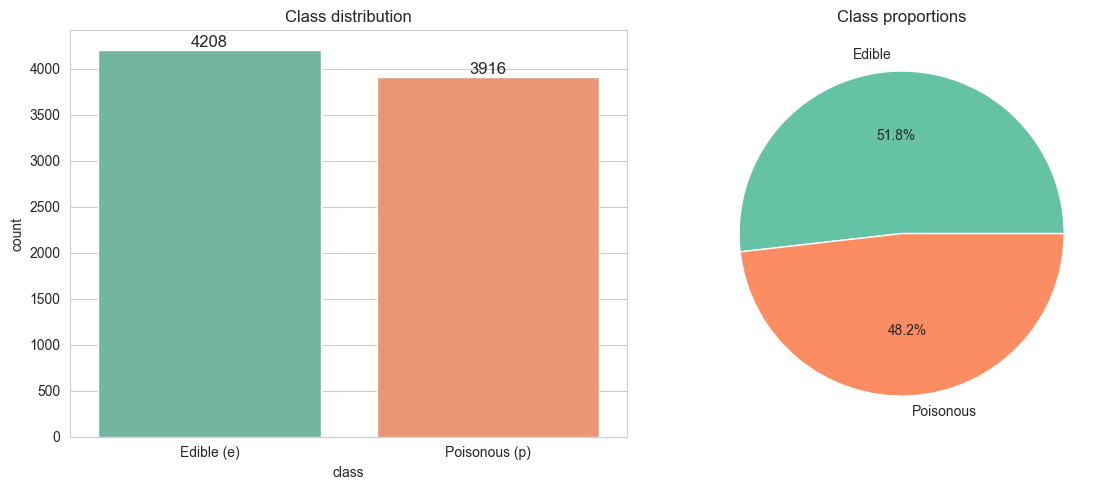

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="class", data=df, palette="Set2", ax=axes[0], order=["e","p"])
axes[0].set_xticklabels(["Edible (e)", "Poisonous (p)"])
axes[0].set_title("Class distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

df["class"].value_counts().plot.pie(
    labels=["Edible","Poisonous"], autopct="%1.1f%%",
    colors=["#66c2a5","#fc8d62"], ax=axes[1])
axes[1].set_ylabel(""); axes[1].set_title("Class proportions")
plt.tight_layout(); plt.show()

## 5. Univariate — Feature Counts

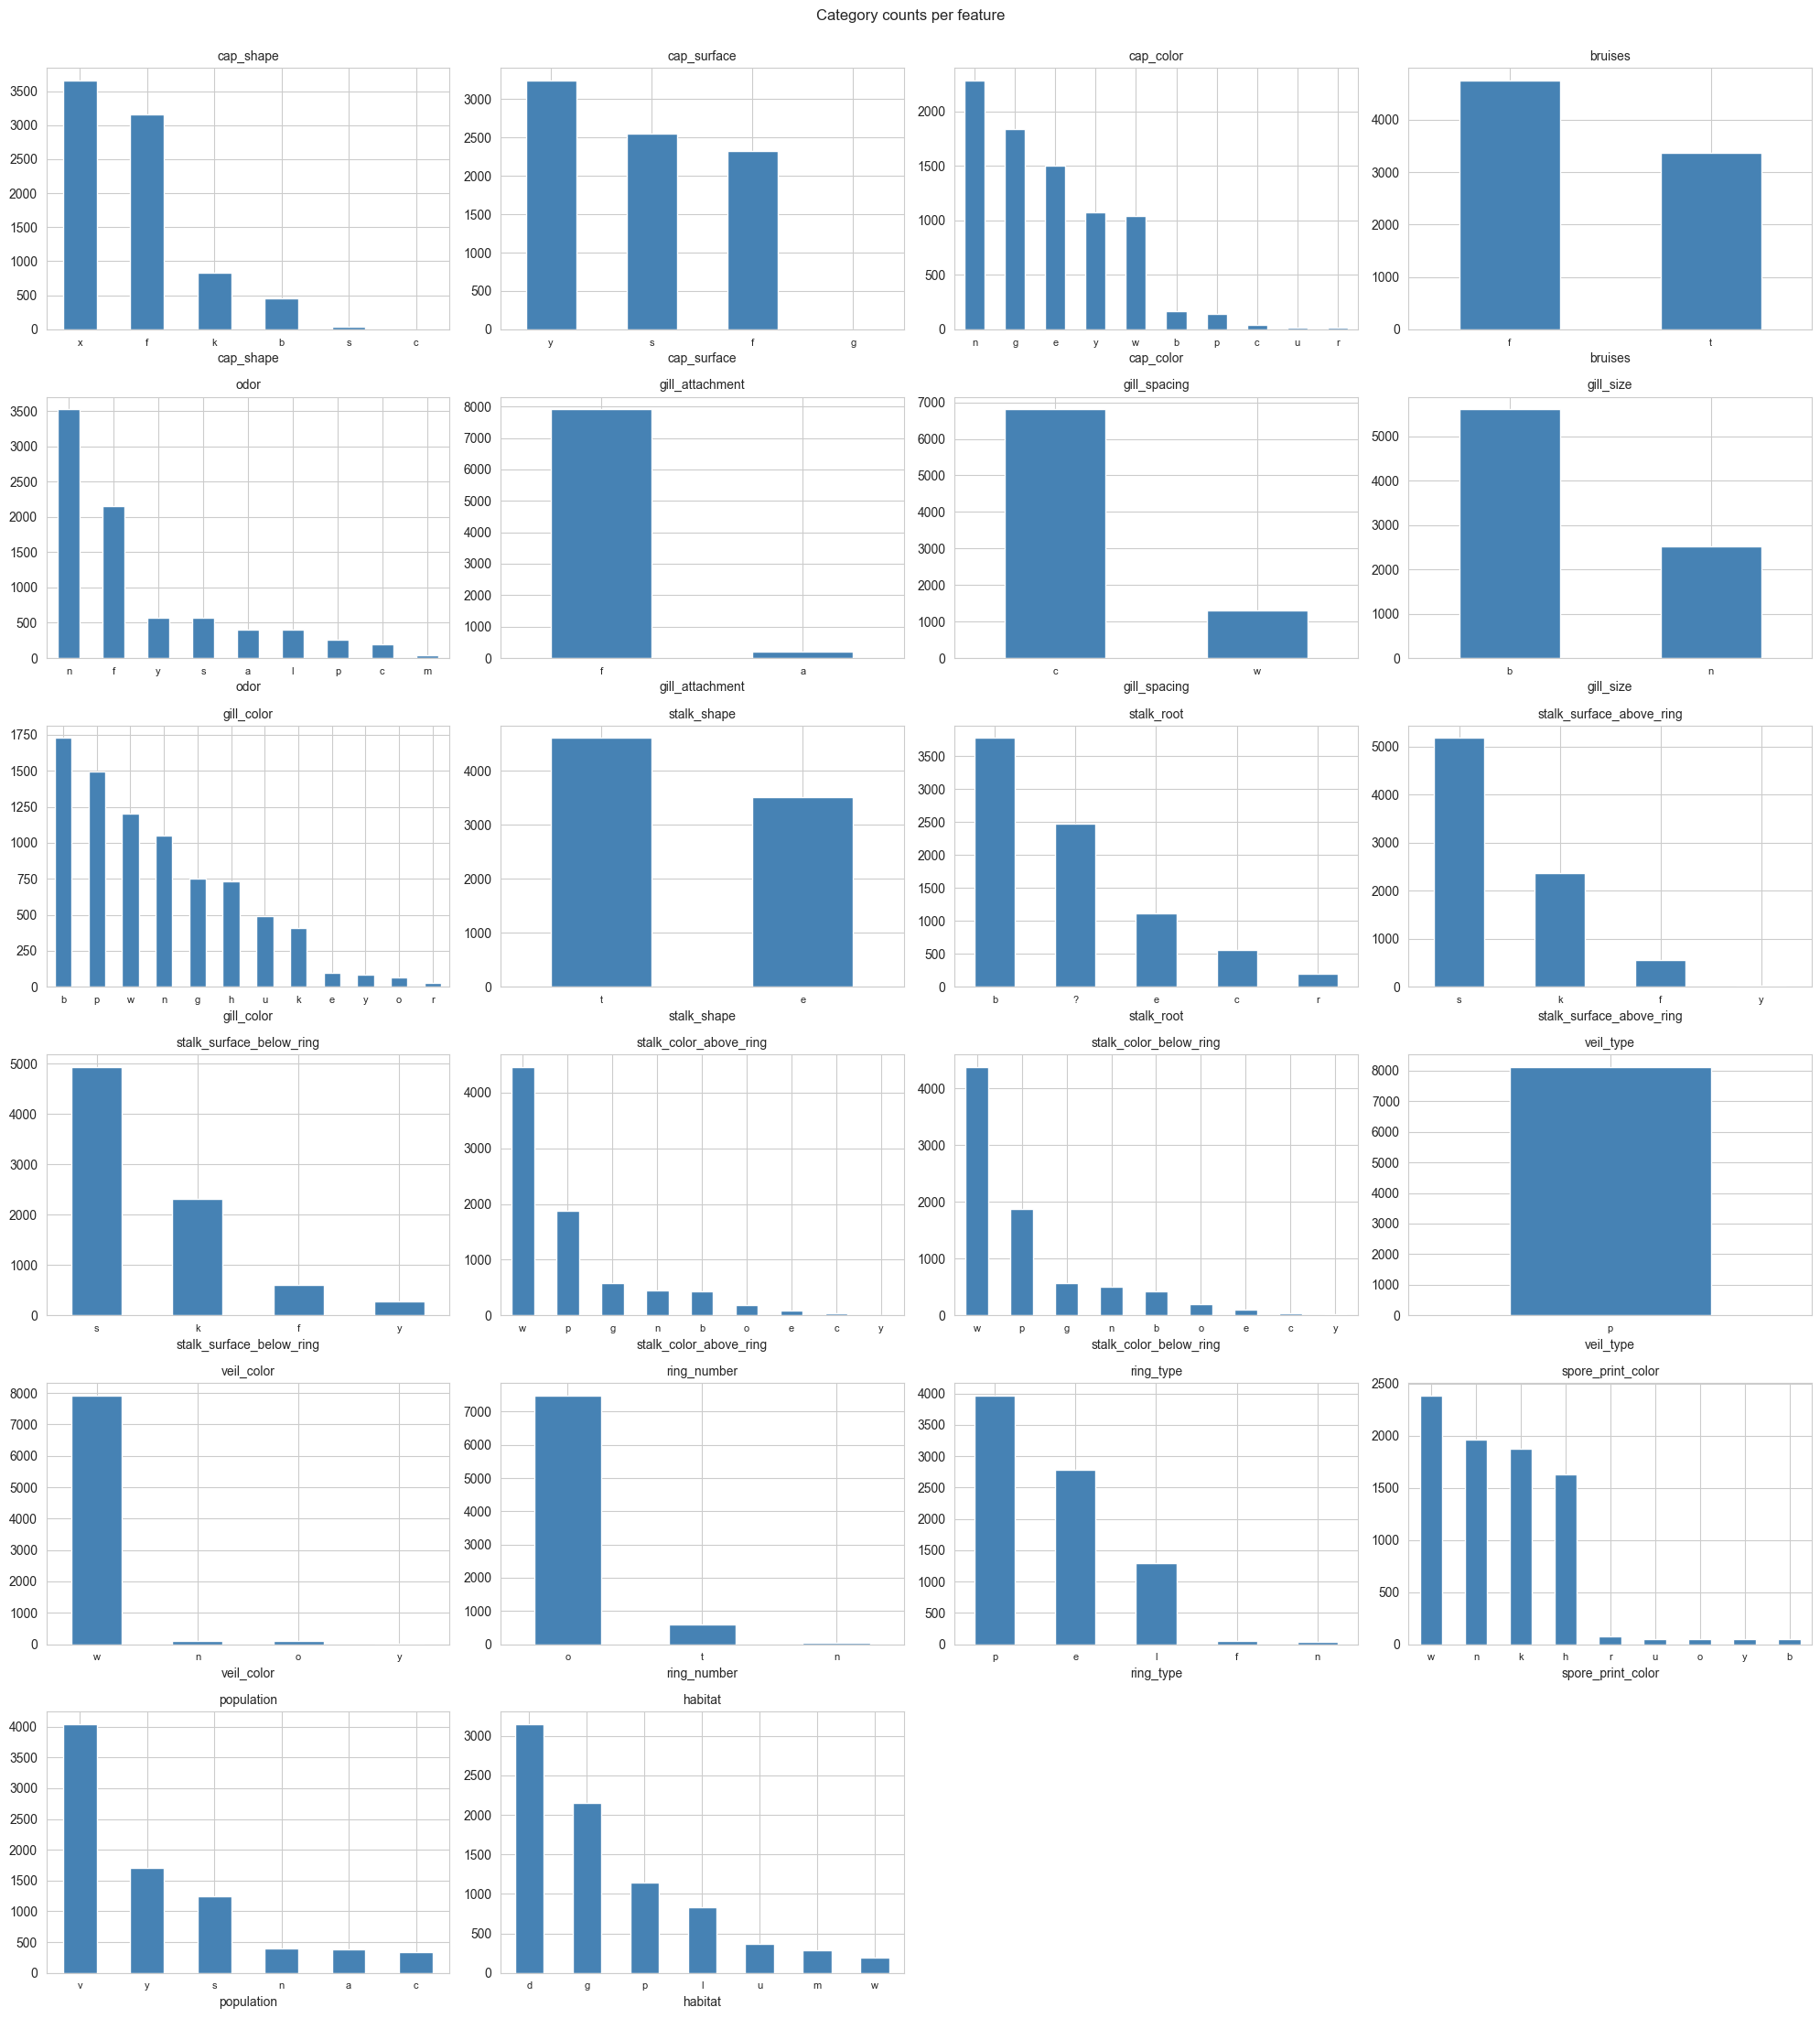

In [7]:
features = [c for c in df.columns if c != "class"]
fig, axes = plt.subplots(6, 4, figsize=(20, 22))
axes = axes.flatten()
for i, col in enumerate(features):
    df[col].value_counts().plot(kind="bar", color="steelblue", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis="x", labelsize=8, rotation=0)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Category counts per feature", y=1.0)
plt.tight_layout(); plt.show()

## 6. Bivariate — Edibility by Feature

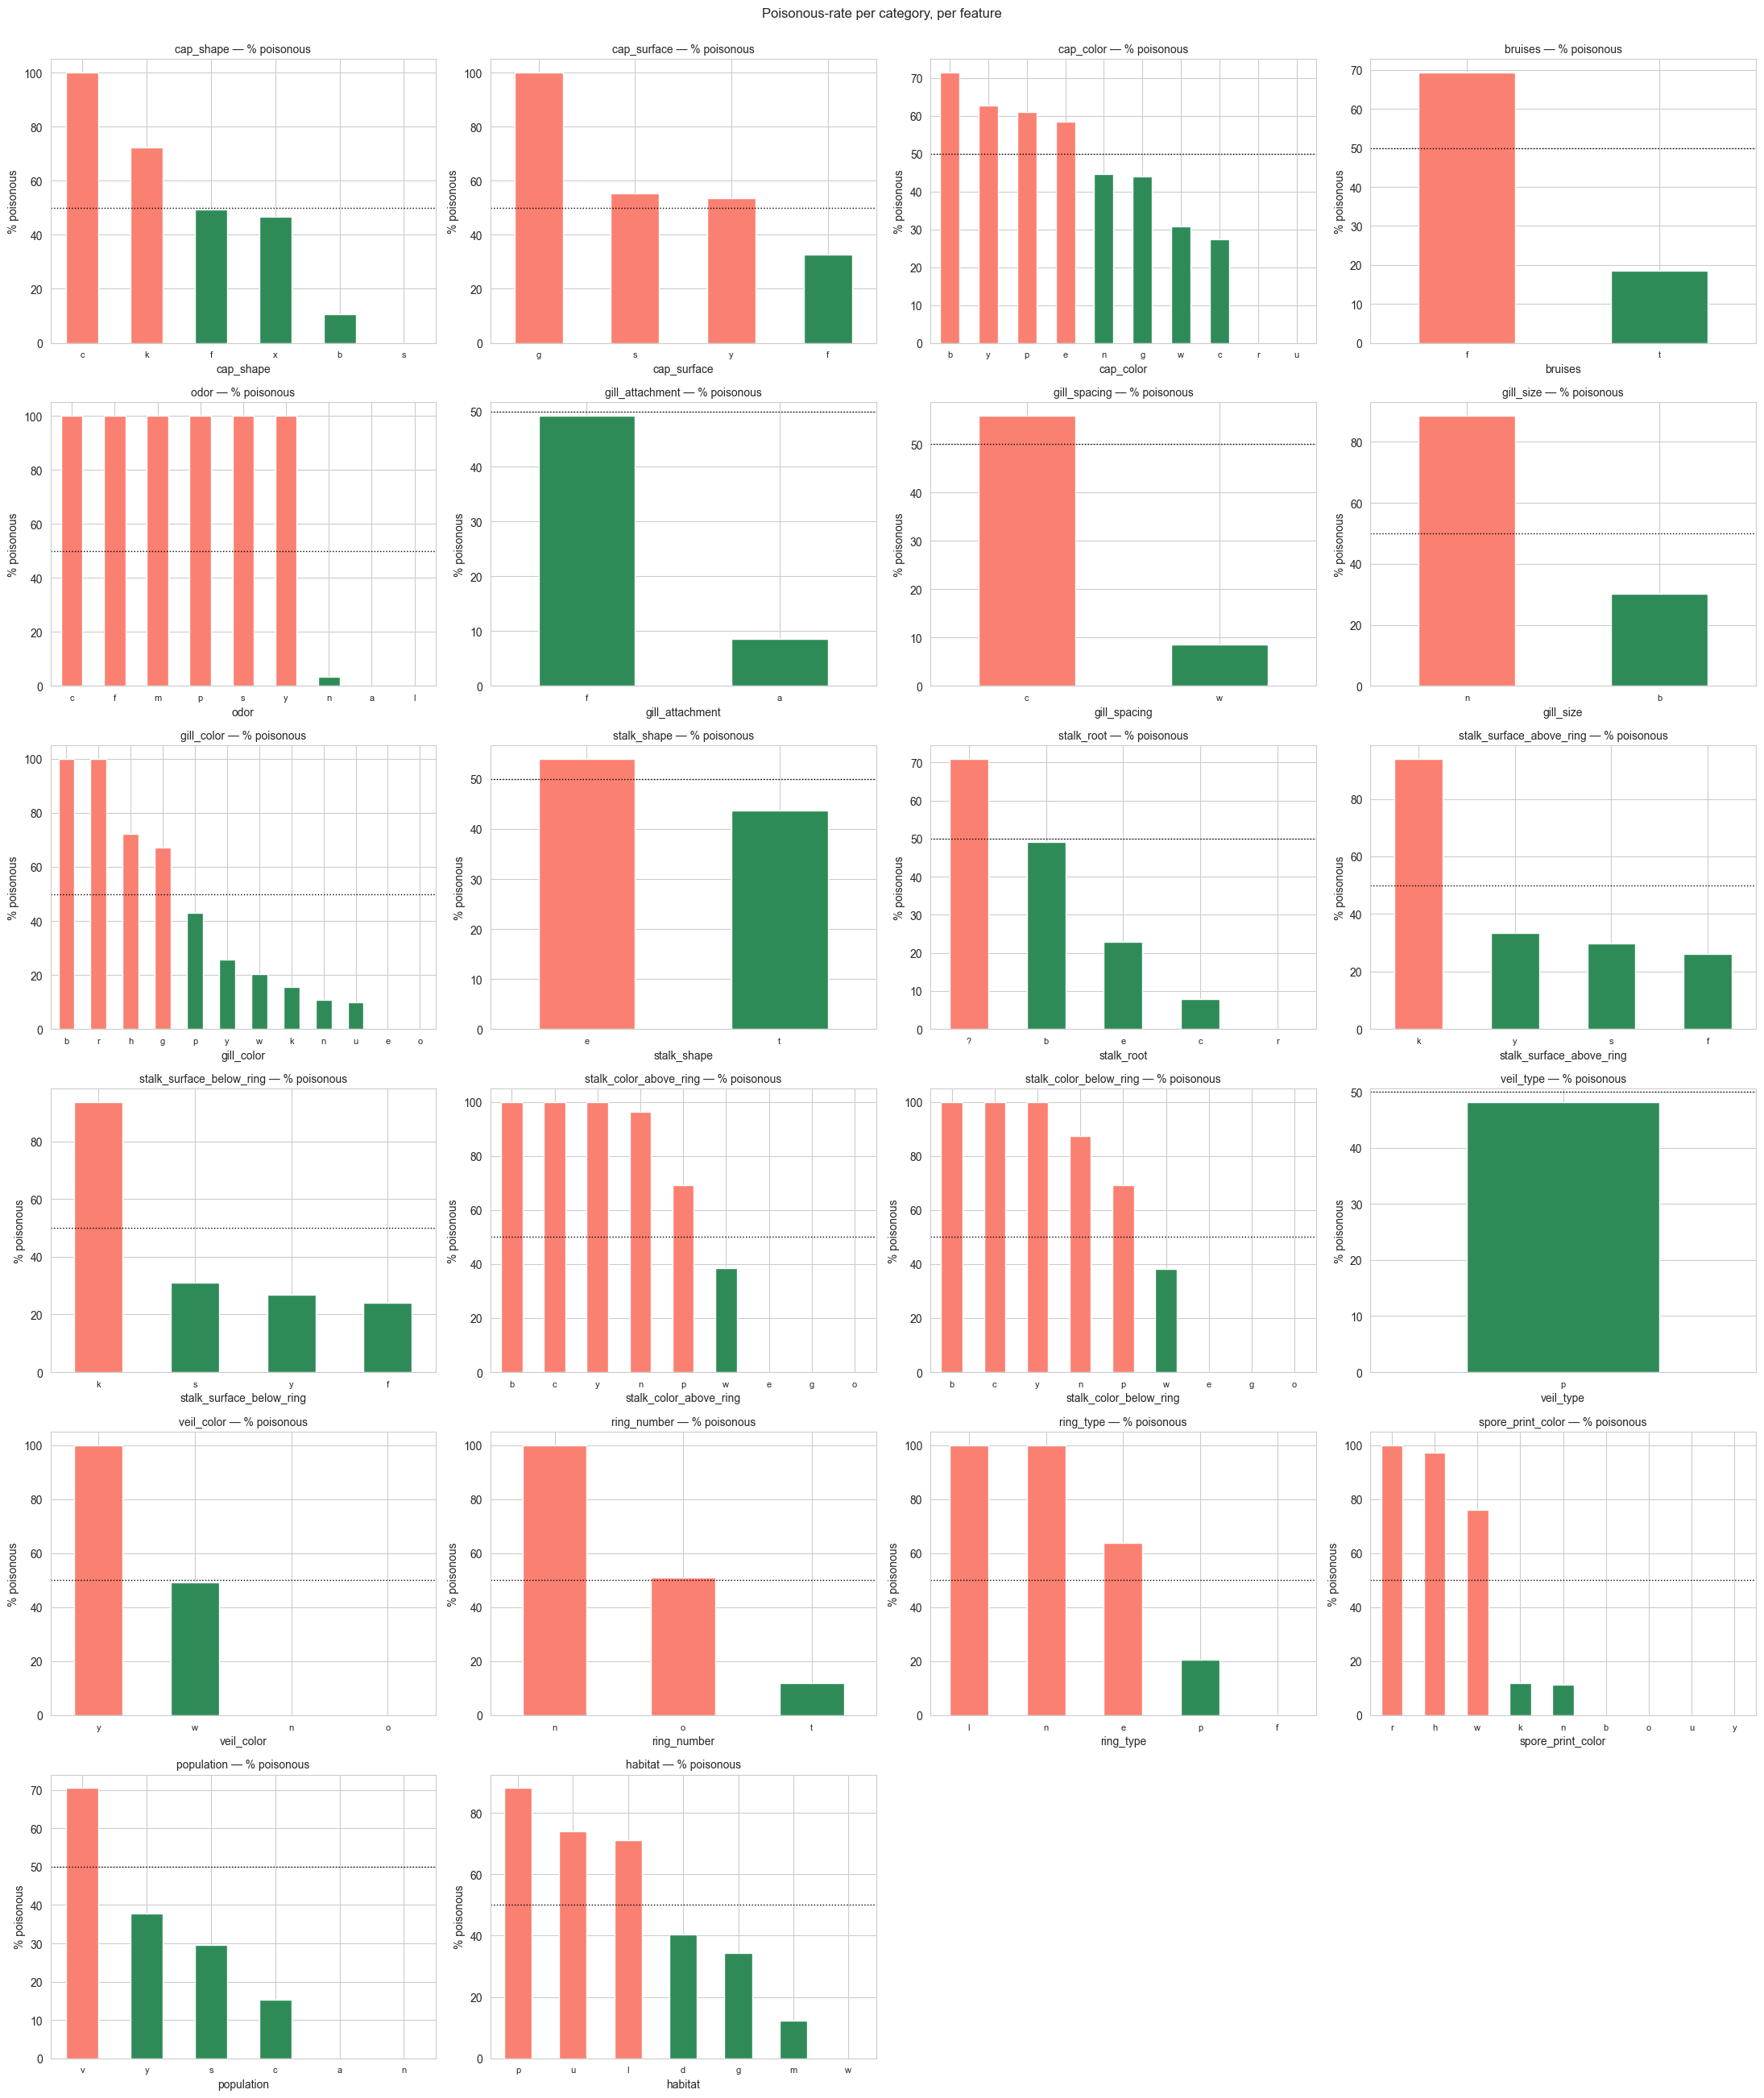

In [8]:
def edibility_rate(df, col):
    return (df.groupby(col)["class"].apply(lambda s: (s=="p").mean())*100).sort_values(ascending=False)

fig, axes = plt.subplots(6, 4, figsize=(22, 26))
axes = axes.flatten()
for i, col in enumerate(features):
    er = edibility_rate(df, col)
    er.plot(kind="bar",
            color=["salmon" if v >= 50 else "seagreen" for v in er],
            ax=axes[i])
    axes[i].axhline(50, color="black", linestyle=":", linewidth=1)
    axes[i].set_title(f"{col} — % poisonous", fontsize=10)
    axes[i].set_ylabel("% poisonous")
    axes[i].tick_params(axis="x", labelsize=8, rotation=0)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Poisonous-rate per category, per feature", y=1.0)
plt.tight_layout(); plt.show()

## 7. Mutual Information — Which Features Matter Most?

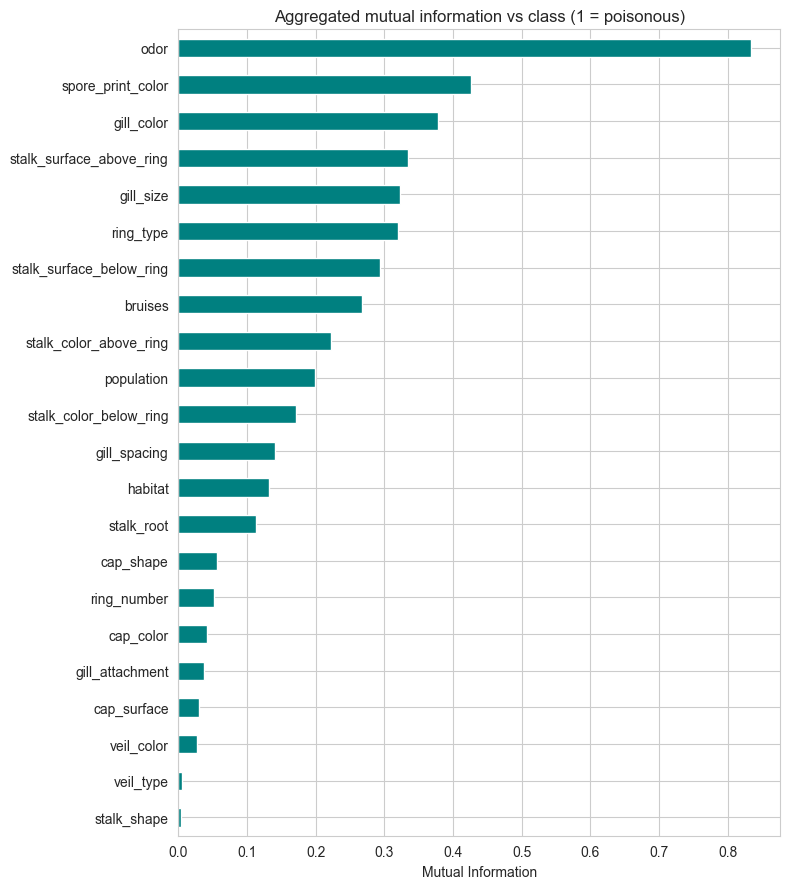

Top 10 features by mutual information:
odor                        0.835
spore_print_color           0.427
gill_color                  0.379
stalk_surface_above_ring    0.334
gill_size                   0.324
ring_type                   0.320
stalk_surface_below_ring    0.294
bruises                     0.267
stalk_color_above_ring      0.223
population                  0.199
dtype: float64


In [9]:
from sklearn.feature_selection import mutual_info_classif
df_enc = df.copy()
df_enc["class"] = df_enc["class"].map({"e":0, "p":1})
df_enc = pd.get_dummies(df_enc, columns=features, drop_first=False)

X_mi = df_enc.drop(columns=["class"])
y_mi = df_enc["class"]
mi_full = pd.Series(mutual_info_classif(X_mi, y_mi, random_state=42), index=X_mi.columns)

# Aggregate one-hot MIs back to base feature
agg = {}
for f in features:
    cols = [c for c in mi_full.index if c.startswith(f+"_")]
    agg[f] = mi_full[cols].sum() if cols else 0.0
mi_agg = pd.Series(agg).sort_values(ascending=True)

plt.figure(figsize=(8, 9))
mi_agg.plot(kind="barh", color="teal")
plt.title("Aggregated mutual information vs class (1 = poisonous)")
plt.xlabel("Mutual Information")
plt.tight_layout(); plt.show()
print("Top 10 features by mutual information:")
print(mi_agg.sort_values(ascending=False).head(10).round(3))

## 8. Odor Deep-Dive (the dominant predictor)

In [10]:
odor_table = pd.crosstab(df["odor"], df["class"], margins=False)
odor_table["% poisonous"] = (odor_table["p"] / (odor_table["e"]+odor_table["p"]) * 100).round(1)
odor_table

class,e,p,% poisonous
odor,,,
a,400,0,0.0
c,0,192,100.0
f,0,2160,100.0
l,400,0,0.0
m,0,36,100.0
n,3408,120,3.4
p,0,256,100.0
s,0,576,100.0
y,0,576,100.0


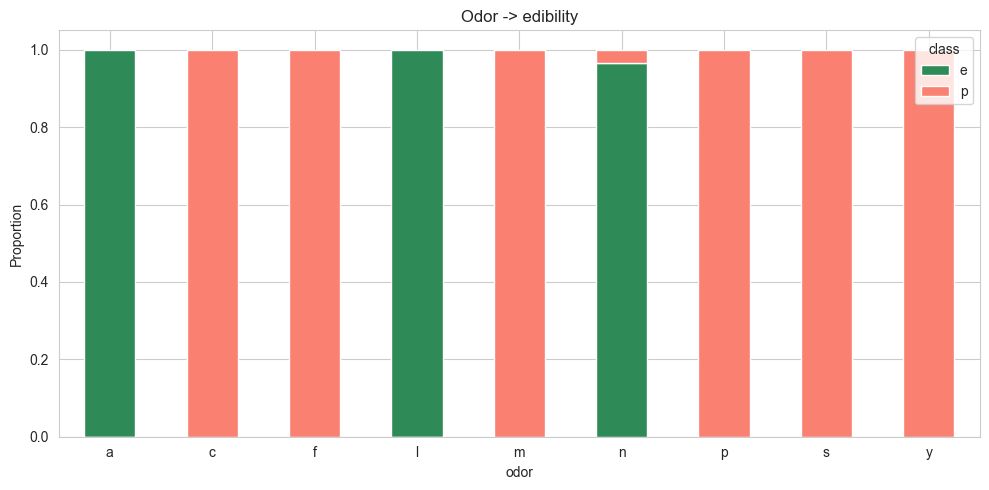

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
pd.crosstab(df["odor"], df["class"], normalize="index").plot(
    kind="bar", stacked=True, color=["seagreen","salmon"], ax=ax)
ax.set_ylabel("Proportion"); ax.set_title("Odor -> edibility")
plt.legend(title="class")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 9. Spore Print Color Deep-Dive

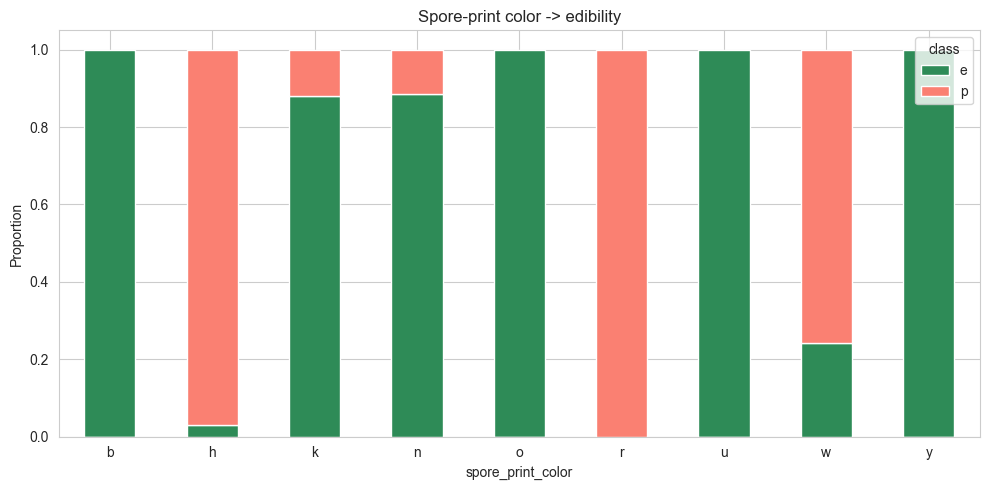

class                 e     p
spore_print_color            
b                    48     0
h                    48  1584
k                  1648   224
n                  1744   224
o                    48     0
r                     0    72
u                    48     0
w                   576  1812
y                    48     0


In [12]:
pd.crosstab(df["spore_print_color"], df["class"], normalize="index").plot(
    kind="bar", stacked=True, color=["seagreen","salmon"], figsize=(10, 5))
plt.title("Spore-print color -> edibility")
plt.ylabel("Proportion")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(pd.crosstab(df["spore_print_color"], df["class"]))

## 10. Pair Plot — Top Categorical Predictors

With 22 categorical features, a numeric pair plot doesn't apply directly. Instead, we show a heat-map of poisonous-rate across the top 4 features by mutual information.

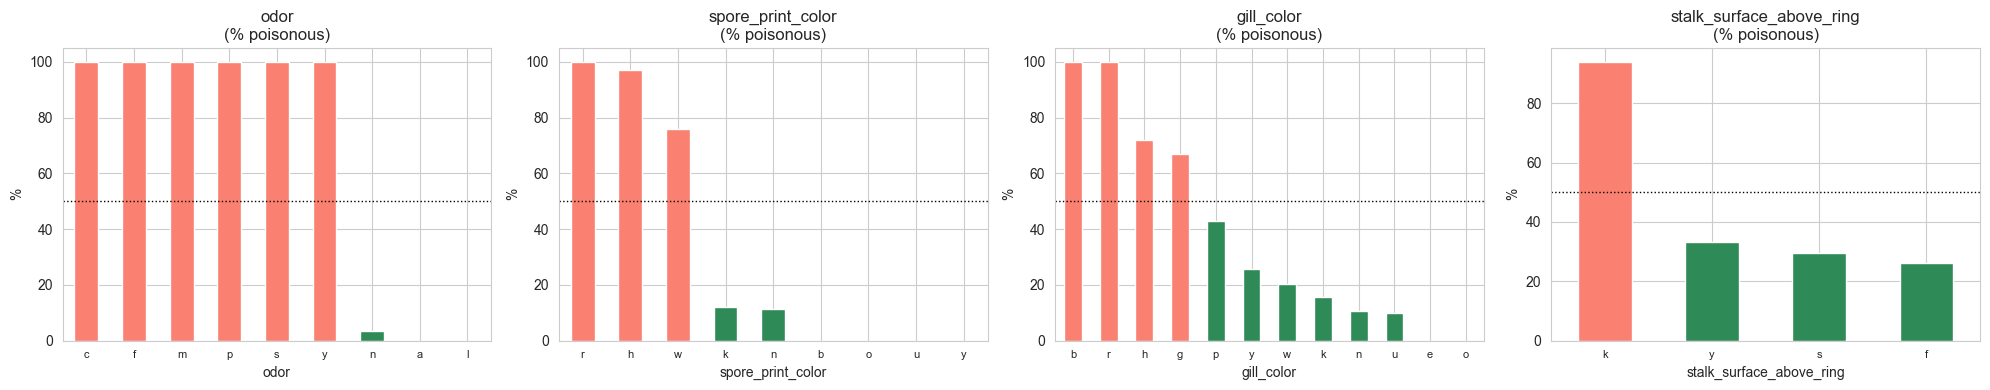

In [13]:
top4 = mi_agg.sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, len(top4), figsize=(5*len(top4), 4))
for i, col in enumerate(top4):
    er = edibility_rate(df, col)
    er.plot(kind="bar", ax=axes[i],
            color=["salmon" if v >= 50 else "seagreen" for v in er])
    axes[i].axhline(50, color="black", linestyle=":", linewidth=1)
    axes[i].set_title(f"{col}\n(% poisonous)")
    axes[i].set_ylabel("%")
    axes[i].tick_params(axis="x", labelsize=8, rotation=0)
plt.tight_layout(); plt.show()

## 11. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Roughly balanced classes**: 51.8% edible, 48.2% poisonous |
| 2 | **Odor is by far the strongest predictor** — wines almond/anise/none correspond almost exclusively to edible mushrooms; foul/fishy/spicy/musty signal poisonous |
| 3 | **Spore-print color, gill-color, ring-type** are the next-most informative |
| 4 | **`stalk_root` has 30.5% missing values** ('?') — the only missing-data column |
| 5 | **`veil_type` is constant** (all "p" = partial) — should be dropped |
| 6 | **Several categories are near-perfect single-class indicators**: e.g. mushrooms with `odor=foul` are 100% poisonous, `odor=almond` are 100% edible |
| 7 | **Most features are quasi-deterministic** — the dataset is famously easy: a small decision tree achieves near-perfect accuracy |